In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import time

# ==========================================
# 1. CARICAMENTO DATI
# ==========================================
print("Caricamento del dataset in corso...")
start_time = time.time()
df = pd.read_csv("freMTPL2_100con_embedding nuovi.csv",sep=",",decimal=".")

# ==========================================
# 2. SEPARAZIONE DELLE VARIABILI
# ==========================================
# Identifichiamo dinamicamente le colonne degli embedding (iniziano per 'E')
colonne_embedding = [col for col in df.columns if col.startswith('E')]
# Identifichiamo le colonne meta (es. IDpol, ClaimAmount, e altre eventuali)
colonne_meta = [col for col in df.columns if col not in colonne_embedding]

df_meta = df[colonne_meta]
X_embeddings = df[colonne_embedding]

print(f"Trovate {len(colonne_meta)} colonne meta e {len(colonne_embedding)} colonne embedding.")

# ==========================================
# 3. STANDARDIZZAZIONE (FONDAMENTALE)
# ==========================================
# La PCA è sensibile alla scala. Standardizzare (media=0, invarianza=1) 
# assicura che tutte le dimensioni dell'embedding contino allo stesso modo.
print("Standardizzazione degli embedding...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embeddings)

# ==========================================
# 4. APPLICAZIONE DELLA PCA
# ==========================================
print("Calcolo delle Componenti Principali (PCA)...")
# Impostando un float (0.85), scikit-learn sceglierà automaticamente 
# il numero minimo di componenti necessarie per spiegare l'85% della varianza.
# Se preferisci un numero fisso (es. 40), cambia n_components=0.85 in n_components=40
pca = PCA(n_components=0.98, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Statistiche dell'operazione
n_componenti_estratte = pca.n_components_
varianza_spiegata = sum(pca.explained_variance_ratio_) * 100

print(f"\n--- RISULTATI PCA ---")
print(f"Dimensioni ridotte da: {len(colonne_embedding)} -> a -> {n_componenti_estratte} componenti.")
print(f"Queste {n_componenti_estratte} colonne mantengono il {varianza_spiegata:.2f}% dell'informazione originale.")

# ==========================================
# 5. RICOSTRUZIONE E SALVATAGGIO
# ==========================================
# Creiamo nomi puliti per le nuove feature (PCA_1, PCA_2, ecc.)
colonne_pca = [f'PCA_{i+1}' for i in range(n_componenti_estratte)]
df_pca = pd.DataFrame(X_pca, columns=colonne_pca, index=df.index)

# Uniamo IDpol e ClaimAmount con i nuovi vettori compressi
df_finale = pd.concat([df_meta, df_pca], axis=1)

nome_output = "freMTPL2_embeddings_PCA.csv"
print(f"\nSalvataggio del nuovo dataset ottimizzato in: {nome_output}...")
df_finale.to_csv(nome_output, index=False)

end_time = time.time()
print(f"[SUCCESSO] Processo completato in {round(end_time - start_time, 2)} secondi!")

Caricamento del dataset in corso...
Trovate 2 colonne meta e 100 colonne embedding.
Standardizzazione degli embedding...
Calcolo delle Componenti Principali (PCA)...

--- RISULTATI PCA ---
Dimensioni ridotte da: 100 -> a -> 87 componenti.
Queste 87 colonne mantengono il 98.08% dell'informazione originale.

Salvataggio del nuovo dataset ottimizzato in: freMTPL2_embeddings_PCA.csv...
[SUCCESSO] Processo completato in 3.95 secondi!


In [2]:
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import time

# ==========================================
# 1. CARICAMENTO E PREPARAZIONE DATI
# ==========================================
print("Caricamento dataset PCA...")
df = pd.read_csv("freMTPL2_embeddings_PCA.csv")

# Definiamo la X (Feature PCA) e la y (Target: Costo)
# Assicurati che 'ClaimAmount' sia il nome esatto della tua colonna costo
X = df.filter(like='PCA_').values
y = df['ClaimAmount'].values
#
def set_seed(seed=42):
    # Fissa il seed per il modulo random di base di Python
    random.seed(seed)
    
    # Fissa il seed per l'hashing di Python (influenza dizionari e set)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Fissa il seed per NumPy
    np.random.seed(seed)
    
    # Fissa il seed per PyTorch (CPU)
    torch.manual_seed(seed)
    
    # Fissa il seed per PyTorch (GPU/CUDA, se disponibile)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Per configurazioni multi-GPU
    
    # Forza comportamenti deterministici nei backend CUDNN (se usi GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Richiama la funzione immediatamente
set_seed(42)
# Split: 80% Training, 20% Test
# Aggiungi gli indici originali (df.index) allo split per non perdere i testi!
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# Convertiamo in tensori PyTorch (float32 è lo standard per le reti neurali)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Creazione dei DataLoader (per passare i dati a "batch" alla rete)
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Dati di Training: {len(X_train)} righe. Dati di Test: {len(X_test)} righe.")
print(f"Feature in input alla Rete Neurale: {X_train.shape[1]}")

# ==========================================
# 2. DEFINIZIONE DELLA RETE NEURALE
# ==========================================
class ActuarialNet(nn.Module):
    def __init__(self, input_size):
        super(ActuarialNet, self).__init__()
        # Architettura a "imbuto" (Deep Neural Network)
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1) # Output finale: il costo predetto
        
        self.relu = nn.ReLU()
        # Il Dropout (20%) spegne casualmente i neuroni per evitare memorizzazione (overfitting)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        # Non c'è attivazione (es. ReLU) sull'ultimo livello perché vogliamo un numero continuo (Regressione)
        x = self.fc4(x)
        
        # Un trucco attuariale: se vuoi forzare l'output a essere solo positivo
        # (visto che non esistono danni a costo negativo), de-commenta la riga sotto:
        # x = torch.exp(x) 
        
        return x

# Inizializziamo il modello
input_dim = X_train.shape[1]
model = ActuarialNet(input_dim)

# ==========================================
# 3. LOSS FUNCTION E OTTIMIZZATORE
# ==========================================
# MAE (L1Loss) è spesso meglio dell'MSE (MSELoss) per i costi assicurativi 
# perché è meno sensibile ai sinistri giganteschi (outliers).
criterion = nn.L1Loss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. IL CICLO DI ADDESTRAMENTO (TRAINING LOOP)
# ==========================================
epochs = 150
print("\nInizio Addestramento...")

for epoch in range(epochs):
    model.train() # Mette il modello in modalità training (attiva il dropout)
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()           # Reset dei gradienti
        predictions = model(batch_X)    # Passaggio in avanti
        loss = criterion(predictions, batch_y) # Calcolo errore
        loss.backward()                 # Passaggio all'indietro (backpropagation)
        optimizer.step()                # Aggiornamento dei pesi
        
        epoch_loss += loss.item()
        
    # Validazione sul Test Set ogni 10 epoche
    if (epoch + 1) % 10 == 0:
        model.eval() # Spegne il dropout per la valutazione
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_loss = criterion(test_preds, y_test_tensor)
        print(f"Epoca {epoch+1}/{epochs} | Train Loss (MAE): {epoch_loss/len(train_loader):.2f} | Test Loss (MAE): {test_loss.item():.2f}")

# ==========================================
# 5. VALUTAZIONE FINALE
# ==========================================
print("\nAddestramento completato.")
model.eval()
with torch.no_grad():
    predizioni_finali = model(X_test_tensor)
    errore_assoluto_medio = criterion(predizioni_finali, y_test_tensor)
    print(f"Errore Assoluto Medio (MAE) Finale sul Test Set: {errore_assoluto_medio.item():.2f} €")

# (Opzionale) Salvataggio del modello addestrato
# torch.save(model.state_dict(), 'modello_sinistri.pth')

Caricamento dataset PCA...
Dati di Training: 21155 righe. Dati di Test: 5289 righe.
Feature in input alla Rete Neurale: 87

Inizio Addestramento...
Epoca 10/150 | Train Loss (MAE): 1266.84 | Test Loss (MAE): 957.09
Epoca 20/150 | Train Loss (MAE): 1209.03 | Test Loss (MAE): 900.53
Epoca 30/150 | Train Loss (MAE): 1163.28 | Test Loss (MAE): 865.24
Epoca 40/150 | Train Loss (MAE): 1126.28 | Test Loss (MAE): 837.18
Epoca 50/150 | Train Loss (MAE): 1077.39 | Test Loss (MAE): 799.36
Epoca 60/150 | Train Loss (MAE): 1039.90 | Test Loss (MAE): 771.10
Epoca 70/150 | Train Loss (MAE): 1011.29 | Test Loss (MAE): 776.24
Epoca 80/150 | Train Loss (MAE): 984.39 | Test Loss (MAE): 773.37
Epoca 90/150 | Train Loss (MAE): 958.38 | Test Loss (MAE): 779.99
Epoca 100/150 | Train Loss (MAE): 952.28 | Test Loss (MAE): 773.36
Epoca 110/150 | Train Loss (MAE): 919.07 | Test Loss (MAE): 781.47
Epoca 120/150 | Train Loss (MAE): 906.31 | Test Loss (MAE): 780.09
Epoca 130/150 | Train Loss (MAE): 883.19 | Test Lo


Generazione del grafico Reale vs Predetto...


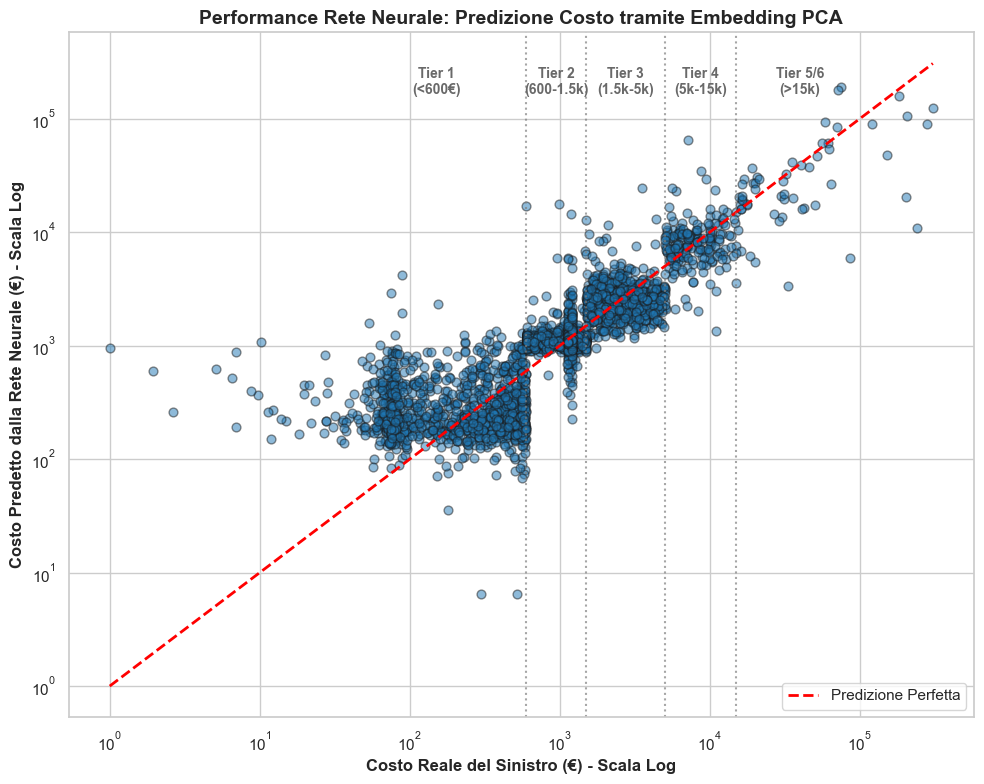

<Figure size 640x480 with 0 Axes>


Generazione Curva di Calibrazione (Spezzata delle Medie)...


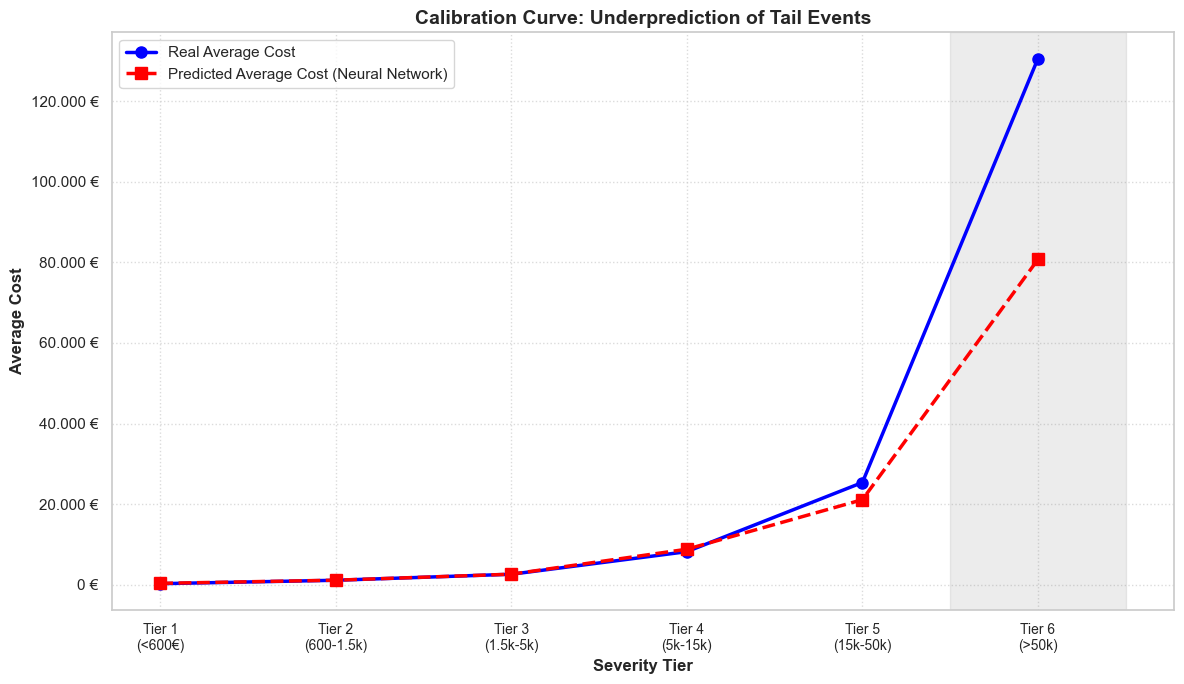


Launching Parametric Triage based on Severity (Threshold)...

--- FINAL BUSINESS RESULTS (ON TEST SET) ---
Triage_Outcome
1. AUTOMATED SETTLEMENT APPROVED               95.37 %
2. MANUAL APPRAISAL REQUIRED (Severe Claim)     4.63 %
Name: proportion, dtype: str

Analysis complete. Data successfully saved to 'parametric_triage_results.csv'.


In [3]:
import os
import random

from matplotlib import ticker
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 6. VISUALIZZAZIONE RISULTATI (ACTUAL VS PREDICTED)
# ==========================================
print("\nGenerazione del grafico Reale vs Predetto...")


# Convertiamo i tensori PyTorch di test in array Numpy per matplotlib
y_true = y_test_tensor.numpy().flatten()
y_pred = predizioni_finali.numpy().flatten()

# Impostiamo lo stile grafico
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Disegniamo i punti (Reale sull'asse X, Predetto sull'asse Y)
# Usiamo un'opacità (alpha) per vedere dove i punti si sovrappongono
plt.scatter(y_true, y_pred, alpha=0.5, color='#1f77b4', edgecolor='k', s=40)

# Disegniamo la linea di "Predizione Perfetta" (x = y)
# Se un punto cade su questa linea rossa, il modello ha indovinato il prezzo esatto
limite_min = min(min(y_true), min(y_pred))
limite_max = max(max(y_true), max(y_pred))
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='red', linestyle='--', linewidth=2, label='Predizione Perfetta')

# Impostiamo la scala logaritmica su entrambi gli assi (cruciale per dati assicurativi)
plt.xscale('log')
plt.yscale('log')

# Etichette e Titolo
plt.xlabel("Costo Reale del Sinistro (€) - Scala Log", fontsize=12, fontweight='bold')
plt.ylabel("Costo Predetto dalla Rete Neurale (€) - Scala Log", fontsize=12, fontweight='bold')
plt.title("Performance Rete Neurale: Predizione Costo tramite Embedding PCA", fontsize=14, fontweight='bold')

# Aggiungiamo i Tier come linee verticali di riferimento
tiers = [600, 1500, 5000, 15000]
for tier in tiers:
    plt.axvline(x=tier, color='gray', linestyle=':', alpha=0.7)

# --- NUOVO: Aggiungiamo i nomi delle classi (Tier) ---
# Usiamo get_xaxis_transform() così la X segue i tuoi dati reali (es. 200€), 
# ma la Y va da 0 (fondo) a 1 (cima del grafico). Mettiamo y=0.95 per scriverli in alto.
trans = plt.gca().get_xaxis_transform()

plt.text(x=150, y=0.95, s='Tier 1\n(<600€)', transform=trans, 
         ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.text(x=950, y=0.95, s='Tier 2\n(600-1.5k)', transform=trans, 
         ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.text(x=2750, y=0.95, s='Tier 3\n(1.5k-5k)', transform=trans, 
         ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.text(x=8660, y=0.95, s='Tier 4\n(5k-15k)', transform=trans, 
         ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.text(x=40000, y=0.95, s='Tier 5/6\n(>15k)', transform=trans, 
         ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

# Annotazioni e Legenda
plt.legend(loc='lower right') # Spostiamo la legenda in basso a destra per non coprire i Tier
plt.tight_layout()

# Salviamo e mostriamo
plt.savefig("grafico_discriminazione_costi_con_classi.png", dpi=300)
plt.show()


# Salviamo e mostriamo
plt.savefig("grafico_discriminazione_costi.png", dpi=300)
plt.show()



# ==========================================
# 7. CURVA DI CALIBRAZIONE E ANALISI DEI TIER 
# ==========================================
print("\nGenerazione Curva di Calibrazione (Spezzata delle Medie)...")

# 1. Creiamo un DataFrame con i risultati del Test Set
df_test_results = pd.DataFrame({
    'Costo_Reale': y_true,      # Dal tuo blocco 6
    'Costo_Predetto': y_pred    # Dal tuo blocco 6
}, index=idx_test)              # Usiamo gli indici salvati allo split!

# 2. Funzione per ricreare i Tier basati sul Costo Reale
def assegna_tier(costo):
    if costo <= 600: return 1
    elif costo <= 1500: return 2
    elif costo <= 5000: return 3
    elif costo <= 15000: return 4
    elif costo <= 50000: return 5
    else: return 6

df_test_results['Tier_Reale'] = df_test_results['Costo_Reale'].apply(assegna_tier)

# 3. Calcolo delle medie per la spezzata
medie_per_tier = df_test_results.groupby('Tier_Reale')[['Costo_Reale', 'Costo_Predetto']].mean().reset_index()

# 4. Creazione del Grafico (Spezzata)
plt.figure(figsize=(12, 7))

# Plot delle linee (leggermente ispessite e con marker più grandi per visibilità)
plt.plot(medie_per_tier['Tier_Reale'], medie_per_tier['Costo_Reale'], 
         marker='o', linestyle='-', color='blue', linewidth=2.5, markersize=8, label='Real Average Cost')
plt.plot(medie_per_tier['Tier_Reale'], medie_per_tier['Costo_Predetto'], 
         marker='s', linestyle='--', color='red', linewidth=2.5, markersize=8, label='Predicted Average Cost (Neural Network)')

plt.title('Calibration Curve: Underprediction of Tail Events', fontsize=14, fontweight='bold')
plt.xlabel('Severity Tier', fontsize=12, fontweight='bold')
plt.ylabel('Average Cost', fontsize=12, fontweight='bold')

# --- MIGLIORAMENTO ASSE X ---
# Sostituiamo i numeri puri (1,2,3...) con le descrizioni delle fasce
custom_x_labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
                   'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']
plt.xticks(ticks=range(1, 7), labels=custom_x_labels, fontsize=10)

# --- MIGLIORAMENTO ASSE Y ---
# Formattiamo i numeri grandi in formato valuta con il punto per le migliaia (es. 25.000 €)
formatter = ticker.FuncFormatter(lambda x, pos: f"{int(x):,} €".replace(",", "."))
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.axvspan(5.5, 6.5, color='gray', alpha=0.15, label='Tail Event (Catastrofale)')

plt.tight_layout()
plt.savefig("grafico_calibrazione_spezzata.png", dpi=300)
plt.show()

# ==========================================
# 8. PARAMETRIC POLICY & CORPORATE TRIAGE
# ==========================================
print("\nLaunching Parametric Triage based on Severity (Threshold)...")

# NOTE: Load the original file containing the raw textual descriptions
# Ensure the file path and name match your local directory
df_text = pd.read_csv("freMTPL2sev con Claim Description.csv") 

# Retrieve ONLY the rows assigned to the Test Set using the saved index split
df_test_text = df_text.loc[idx_test].copy()

# Merge the original texts with the predictions computed in the previous blocks
df_business = pd.concat([df_test_text, df_test_results[['Costo_Predetto', 'Tier_Reale']]], axis=1)

# 1. Parametric Policy Logic (Pure Financial Threshold)
def parametric_triage(row):
    predicted_cost = row['Costo_Predetto']
    
    # Rule: Automated payment if the predicted cost is <= 5000€ (Up to Tier 3)
    if predicted_cost <= 5000:
        return '1. AUTOMATED SETTLEMENT APPROVED'
    # If the cost falls into Tier 4, 5, or 6 (> 5000€), trigger human routing
    else:
        return '2. MANUAL APPRAISAL REQUIRED (Severe Claim)'

# 2. Apply the Triage Rule and Calculate Final Distributions
df_business['Triage_Outcome'] = df_business.apply(parametric_triage, axis=1)

print("\n--- FINAL BUSINESS RESULTS (ON TEST SET) ---")
# Calculate percentages clean, rounded, and formatted
percentages = df_business['Triage_Outcome'].value_counts(normalize=True) * 100
print(percentages.round(2).astype(str) + ' %')

# 3. Export the Business DataFrame for Thesis Reporting
df_business.to_csv("parametric_triage_results.csv", index=False)
print("\nAnalysis complete. Data successfully saved to 'parametric_triage_results.csv'.")

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Convertiamo i tensori PyTorch (della tua Sezione 5) in array NumPy 1D
y_true = y_test_tensor.numpy().flatten()
y_pred = predizioni_finali.numpy().flatten()

# 2. Creiamo un DataFrame con i costi reali e quelli predetti
results_df = pd.DataFrame({
    'Costo_Reale': y_true,
    'Costo_Predetto': y_pred
})

# 3. Definiamo i confini delle tue classi (Tiers) basati sui grafici
bins = [0, 600, 1500, 5000, 15000, 50000, np.inf]
labels_tier = [
    'Tier 1 (<600€)', 
    'Tier 2 (600-1.5k)', 
    'Tier 3 (1.5k-5k)',
    'Tier 4 (5k-15k)', 
    'Tier 5 (15k-50k)', 
    'Tier 6 (>50k)'
]

# 4. Assegniamo ogni sinistro al suo Tier in base al Costo REALE
results_df['Tier'] = pd.cut(results_df['Costo_Reale'], bins=bins, labels=labels_tier)

# 5. Funzione per calcolare l'RMSE su un singolo gruppo
def calculate_rmse(group):
    # Evita errori se un Tier è vuoto nel test set
    if len(group) == 0:
        return np.nan
    return np.sqrt(mean_squared_error(group['Costo_Reale'], group['Costo_Predetto']))

# 6. Raggruppiamo per 'Tier' e applichiamo la funzione
rmse_per_tier = results_df.groupby('Tier', observed=False).apply(calculate_rmse).reset_index()
rmse_per_tier.columns = ['Severity Tier', 'RMSE (€)']

# (Opzionale) Aggiungiamo anche il conteggio dei sinistri per capire il peso di ogni classe
conteggio = results_df['Tier'].value_counts().reset_index()
conteggio.columns = ['Severity Tier', 'Numero_Sinistri']
analisi_completa = pd.merge(rmse_per_tier, conteggio, on='Severity Tier')

print("\n--- Analisi RMSE per Classe di Gravità ---")
print(analisi_completa.to_string(index=False))


--- Analisi RMSE per Classe di Gravità ---
    Severity Tier      RMSE (€)  Numero_Sinistri
   Tier 1 (<600€)    593.985243             1113
Tier 2 (600-1.5k)    497.762211             3137
 Tier 3 (1.5k-5k)   1590.801528              797
  Tier 4 (5k-15k)   6343.480433              187
 Tier 5 (15k-50k)  12803.953140               37
    Tier 6 (>50k) 109082.790137               18


In [5]:
# ==========================================
# INDAGINE ANOMALIE: CLUSTER TIER 1 -> TIER 2
# ==========================================
print("\n🔍 Estrazione delle anomalie in corso...")

# 1. Carichiamo il dataset originale che contiene le descrizioni di testo
df_text_originale = pd.read_csv("freMTPL2sev con Claim Description e VehBrand_Variability.csv") 

# Recuperiamo SOLO le descrizioni del test set usando gli indici salvati nello split (idx_test)
# Usiamo .values per trasformarlo in un array compatibile con y_true e y_pred
descrizioni_test = df_text_originale.loc[idx_test, 'Claim_Description'].values

# 2. Creiamo un DataFrame combinando i valori reali, predetti e i testi
df_analisi = pd.DataFrame({
    'Costo_Reale': y_true,
    'Costo_Predetto': y_pred,
    'Claim_Description': descrizioni_test
})

# 3. Filtriamo ESATTAMENTE la zona fucsia
# Condizione: Reale basso (< 600) MA Predetto alto (es. >= 800)
cluster_anomalo = df_analisi[(df_analisi['Costo_Reale'] < 600) & (df_analisi['Costo_Predetto'] >= 800)]

print(f"Trovate {len(cluster_anomalo)} righe anomale (Falsi Positivi).")

# 4. Mostriamo le prime 10 anomalie a schermo per un controllo rapido
# Impostiamo pandas per non tagliare il testo a metà nel terminale
pd.set_option('display.max_colwidth', None)
print(cluster_anomalo[['Costo_Reale', 'Costo_Predetto', 'Claim_Description']].head(10))

# 5. Salviamo su file per un'analisi approfondita
cluster_anomalo.to_csv("analisi_cluster_fucsia.csv", index=False)
print("File 'analisi_cluster_fucsia.csv' salvato. Puoi aprirlo su Excel per leggere le descrizioni!")


🔍 Estrazione delle anomalie in corso...
Trovate 64 righe anomale (Falsi Positivi).
     Costo_Reale  Costo_Predetto  \
264   235.270004     1055.773071   
414   314.230011      852.611328   
444   575.159973      915.592529   
545    76.629997      896.225708   
575   493.679993      966.151184   
580   564.059998     1285.806396   
633    75.980003      854.380920   
675   556.140015      933.156799   
696    75.320000     2921.509521   
707   232.000000      902.704895   

                                                                                                                                                                                                                                                                 Claim_Description  
264                                                                                                                                                                                  The B12's uppermost surface features minute depressions, char

Caricamento del dataset 'freMTPL2_100con_embedding nuovi.csv'...
Trovati 15709 sinistri in questa fascia di prezzo.


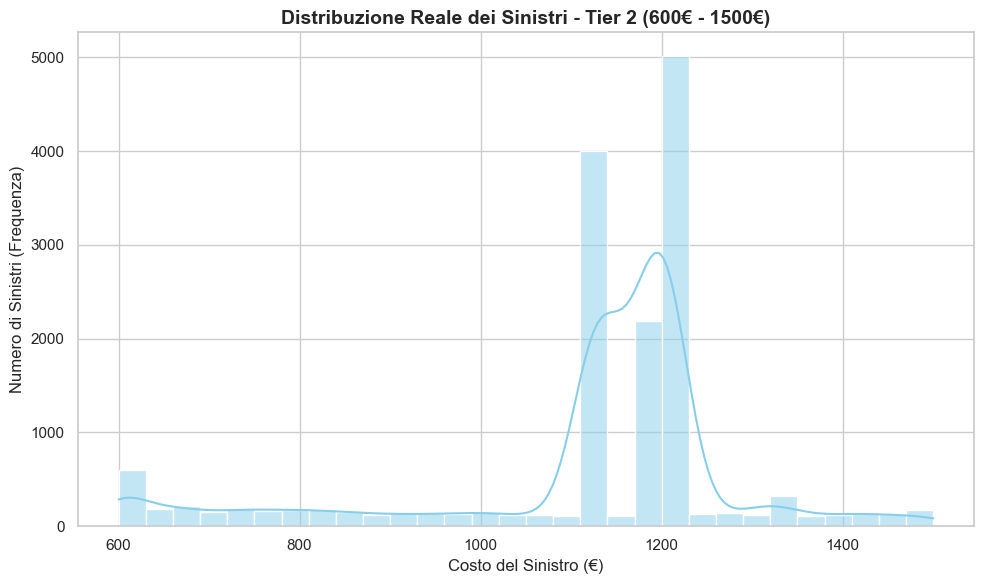

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nome del tuo file
file_input = "freMTPL2_100con_embedding nuovi.csv"

print(f"Caricamento del dataset '{file_input}'...")
df = pd.read_csv(file_input)

# 1. Filtriamo il dataset prendendo SOLO le righe dove ClaimAmount è tra 600 e 1500
df_tier2 = df[(df['ClaimAmount'] >= 600) & (df['ClaimAmount'] <= 1500)]

print(f"Trovati {len(df_tier2)} sinistri in questa fascia di prezzo.")

# 2. Impostiamo l'aspetto del grafico per renderlo pulito e professionale
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Disegniamo l'istogramma con la curva di densità (KDE)
sns.histplot(
    data=df_tier2, 
    x='ClaimAmount', 
    bins=30,           # Numero di "colonnine" dell'istogramma
    kde=True,          # Disegna la linea curva morbida sopra le colonne
    color="skyblue", 
    edgecolor="white"
)

# 4. Aggiungiamo titoli e etichette
plt.title("Distribuzione Reale dei Sinistri - Tier 2 (600€ - 1500€)", fontsize=14, fontweight='bold')
plt.xlabel("Costo del Sinistro (€)", fontsize=12)
plt.ylabel("Numero di Sinistri (Frequenza)", fontsize=12)

# 5. Mostriamo il risultato
plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# EXTRA: ANALISI DATI REALI VS PREDETTI (Fino al Tier 4)
# ==========================================
print("\nEstrazione dei dati reali e predetti fino al Tier 4...")

# 1. Filtriamo il DataFrame per includere solo i Tier da 1 a 4
df_fino_al_tier4 = df_test_results[df_test_results['Tier_Reale'] <= 4].copy()

# 2. Calcoliamo la differenza assoluta per capire di quanto sbaglia la rete
df_fino_al_tier4['Errore_Assoluto'] = abs(df_fino_al_tier4['Costo_Reale'] - df_fino_al_tier4['Costo_Predetto'])

# 3. Ordiniamo i dati per Tier e poi per Costo Reale (per una lettura più pulita)
df_fino_al_tier4 = df_fino_al_tier4.sort_values(by=['Tier_Reale', 'Costo_Reale'])

# 4. Stampiamo a video i primi e gli ultimi 20 record per avere un'idea immediata
print("\n--- PRIMI 20 RECORD (Tier bassi) ---")
print(df_fino_al_tier4.head(20).round(2))

print("\n--- ULTIMI 20 RECORD (Tier 4) ---")
print(df_fino_al_tier4.tail(20).round(2))

# 5. Salviamo l'intero subset in un file CSV per poterlo aprire con Excel e guardare ogni singola riga
nome_file = "dettaglio_predizioni_tier1_4.csv"
df_fino_al_tier4.round(2).to_csv(nome_file)
print(f"\nTutti i dati fino al Tier 4 sono stati salvati con successo nel file: '{nome_file}'.")


Estrazione dei dati reali e predetti fino al Tier 4...

--- PRIMI 20 RECORD (Tier bassi) ---
       Costo_Reale  Costo_Predetto  Tier_Reale  Errore_Assoluto
7794      1.000000      945.169983           1       944.169983
1266      1.950000      604.210022           1       602.260010
10746     2.630000      260.470001           1       257.839996
8034      5.080000      623.859985           1       618.780029
21080     6.520000      514.159973           1       507.640015
22117     6.910000      877.270020           1       870.359985
18232     6.960000      190.059998           1       183.100006
7107      8.810000      402.089996           1       393.279999
16196     9.680000      364.630005           1       354.950012
2308     10.200000     1081.880005           1      1071.680054
9040     11.280000      260.260010           1       248.979996
10855    11.910000      150.190002           1       138.279999
9952     12.200000      272.500000           1       260.299988
9403     1


Generating Calibration Curve (Median Trendline)...


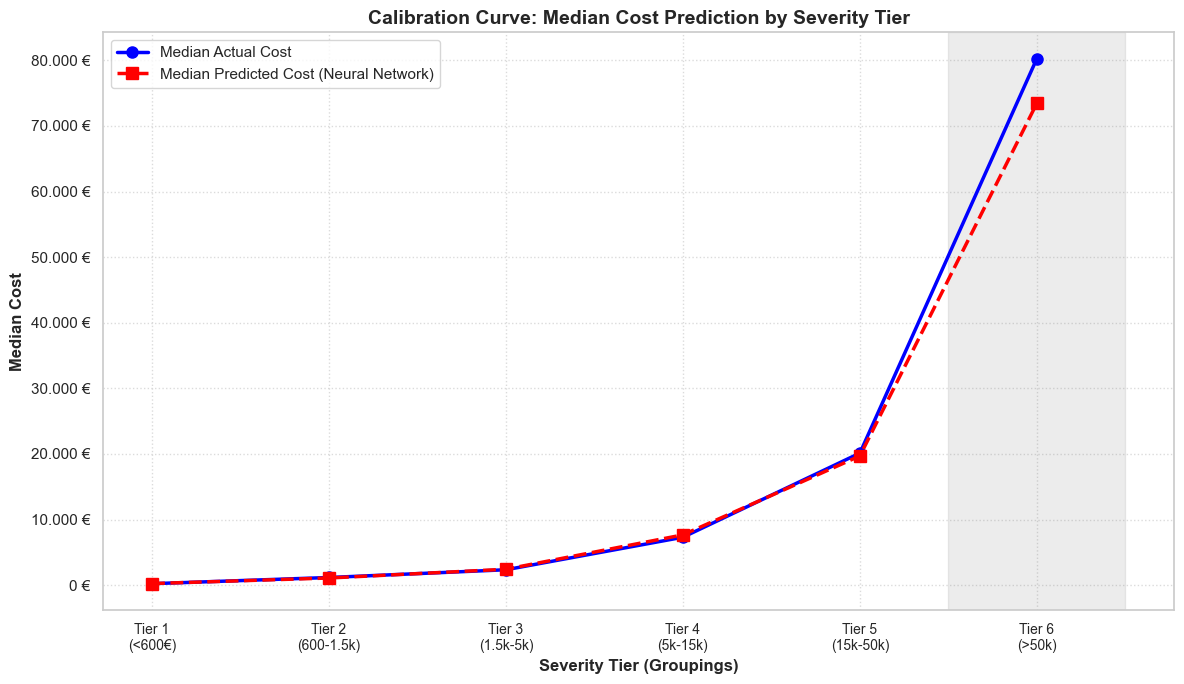

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# 7. CALIBRATION CURVE AND TIER ANALYSIS (MEDIAN)
# ==========================================
print("\nGenerating Calibration Curve (Median Trendline)...")

# 1. Create a DataFrame with the Test Set results
df_test_results = pd.DataFrame({
    'Costo_Reale': y_true,      # From your block 6
    'Costo_Predetto': y_pred    # From your block 6
}, index=idx_test)              # Use the indices saved during the split!

# 2. Function to recreate the Tiers based on Actual Cost
def assign_tier(cost):
    if cost <= 600: return 1
    elif cost <= 1500: return 2
    elif cost <= 5000: return 3
    elif cost <= 15000: return 4
    elif cost <= 50000: return 5
    else: return 6

df_test_results['Tier_Reale'] = df_test_results['Costo_Reale'].apply(assign_tier)

# 3. Compute MEDIANS for the trendline (Replaced .mean() with .median())
medians_per_tier = df_test_results.groupby('Tier_Reale')[['Costo_Reale', 'Costo_Predetto']].median().reset_index()

# 4. Plot Creation (Median Trendline)
plt.figure(figsize=(12, 7))

# Plot lines based on the median values
plt.plot(medians_per_tier['Tier_Reale'], medians_per_tier['Costo_Reale'], 
         marker='o', linestyle='-', color='blue', linewidth=2.5, markersize=8, label='Median Actual Cost')
plt.plot(medians_per_tier['Tier_Reale'], medians_per_tier['Costo_Predetto'], 
         marker='s', linestyle='--', color='red', linewidth=2.5, markersize=8, label='Median Predicted Cost (Neural Network)')

plt.title('Calibration Curve: Median Cost Prediction by Severity Tier', fontsize=14, fontweight='bold')
plt.xlabel('Severity Tier (Groupings)', fontsize=12, fontweight='bold')
plt.ylabel('Median Cost', fontsize=12, fontweight='bold')

# --- X-AXIS IMPROVEMENT ---
# Replace raw numbers (1, 2, 3...) with descriptive bracket labels
custom_x_labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
                   'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']
plt.xticks(ticks=range(1, 7), labels=custom_x_labels, fontsize=10)

# --- Y-AXIS IMPROVEMENT ---
# Format large numbers into currency style with dot thousands separators (e.g., 25.000 €)
formatter = ticker.FuncFormatter(lambda x, pos: f"{int(x):,} €".replace(",", "."))
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.axvspan(5.5, 6.5, color='gray', alpha=0.15, label='Tail Event (Catastrophic)')

plt.tight_layout()
# Save with a unique filename to prevent overwriting the mean-based chart
plt.savefig("median_calibration_curve.png", dpi=300)
plt.show()

In [9]:
# 1. Carica il file originale (Assicurati che sia quello giusto)
df_originale = pd.read_csv("freMTPL2sev con Claim Description.csv")

# 2. Crea una lista degli indici che avevi nel Test Set
# (Assicurati di aver salvato idx_test nel tuo script precedente)
indici_da_cercare = idx_test

# 3. Estrai le righe dal file originale usando .loc
# Questo ti darà esattamente le righe che corrispondono al tuo Test Set
df_confronto = df_originale.loc[indici_da_cercare]

# 4. Aggiungi i costi predetti per confronto
df_confronto['Costo_Predetto'] = y_pred

# 5. Salva in un nuovo file CSV
df_confronto.to_csv("confronto_reale_predetto_preciso.csv")
print("File salvato: ora puoi aprire 'confronto_reale_predetto_preciso.csv' e trovare i valori esatti.")

File salvato: ora puoi aprire 'confronto_reale_predetto_preciso.csv' e trovare i valori esatti.


In [10]:
dff=pd.read_csv('confronto_reale_predetto_preciso.csv')
print(dff)

      Unnamed: 0    IDpol  ClaimAmount  \
0          15276  2061957      1246.15   
1           1901  6037414      1320.00   
2           7356  1118692      1128.12   
3          11995  2116328      2860.12   
4          13035  2109190       392.80   
...          ...      ...          ...   
5284       13475  2080842        81.39   
5285       18496  3204788      1204.00   
5286       12517    87885      1128.12   
5287        8088  1067850      1128.00   
5288        7505  1159764      1128.00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## 5. Cost-Benefit Analysis: Il Business Case del Triage Parametrico

L'efficacia di un modello di Machine Learning applicato al settore Insurtech non può essere valutata esclusivamente attraverso metriche di errore statistico (come il MAE o l'RMSE). Per dimostrarne la reale sostenibilità in un ambiente di produzione, è necessario tradurre la performance predittiva in **Ritorno sull'Investimento (ROI)**.

In questa sezione viene condotta un'**Analisi Costi-Benefici** sulle pratiche approvate per il pagamento automatico (*Straight-Through Processing - STP*). La logica finanziaria si basa sulla quantificazione del risparmio operativo derivante dalla mancata attivazione della perizia tradizionale.

Per ogni singolo sinistro automatizzato, il **Risparmio Netto** per la compagnia viene calcolato secondo la seguente formula:

$$\text{Risparmio Netto} = (\text{Costo Reale} + \text{Costo Operativo Perito}) - \text{Costo Predetto (Pagato)}$$

Dove:
* **Costo Reale:** L'importo effettivo del danno.
* **Costo Operativo Perito:** Il costo fisso per l'uscita e la gestione della pratica da parte di un liquidatore umano (assunto cautelativamente a $150€$).
* **Costo Predetto:** L'importo forfettario proposto dalla Rete Neurale e accettato dal cliente.

Il blocco di codice seguente isola il sottoinsieme di pratiche approvate dal filtro di Sentiment Analysis e calcola il bilancio finanziario complessivo sul Test Set.

In [11]:
# ==========================================
# 9. FINANCIAL ANALYSIS & BUSINESS CASE
# ==========================================
print("\n" + "="*55)
print(" FINANCIAL ANALYSIS (REAL BUSINESS CASE)")
print("="*55)

# 1. Integrate the Real Cost (if not already in df_business) for calculations
if 'Costo_Reale' not in df_business.columns:
    df_business['Costo_Reale'] = df_test_results['Costo_Reale']

# 2. Filter ONLY the claims under the threshold (STP - Straight Through Processing)
# Aggiornato con il nome corretto della colonna in inglese: 'Triage_Outcome'
df_approved = df_business[df_business['Triage_Outcome'] == '1. AUTOMATED SETTLEMENT APPROVED']
total_proposed = len(df_approved)

# 3. Financial Parameters (Actuarial Assumptions)
acceptance_rate = 0.80     # Estimated 80% of clients accept the instant settlement
unit_adjuster_cost = 150.0 # Average saved cost per claim (LAE - Loss Adjustment Expense)

# Volume Calculations
accepted_offers = int(total_proposed * acceptance_rate)
rejected_offers = total_proposed - accepted_offers

# 4. Calculation of Savings and Margins
# The adjuster savings are achieved ONLY if the client accepts the offer
adjusters_savings = accepted_offers * unit_adjuster_cost

# The "Delta" is the difference between the real damage (what would have been paid with an adjuster)
# and the predicted damage (what is paid automatically).
# We multiply the total delta by 80% (acceptance rate).
total_delta_approved = (df_approved['Costo_Reale'] - df_approved['Costo_Predetto']).sum()
delta_accepted_payments = total_delta_approved * acceptance_rate

# Total Profit
total_net_profit = adjusters_savings + delta_accepted_payments
average_profit_per_claim = total_net_profit / accepted_offers if accepted_offers > 0 else 0

# 5. Business Case Console Output
print(f"Proposed Automated Offers: {total_proposed}")
print(f"Offers Accepted by Clients ({acceptance_rate*100}%): {accepted_offers}")
print(f"Rejected Offers (Routed to Adjuster): {rejected_offers}")
print("-" * 55)
print(f"Operational Cost (Adjusters) Saved: + {adjusters_savings:,.2f} €")
print(f"Payment Delta (Real vs Predicted): {delta_accepted_payments:,.2f} €")
print("-" * 55)
print(f"✅ ACTUAL NET PROFIT GENERATED: + {total_net_profit:,.2f} €")
print(f"✅ Average profit per ACCEPTED claim: + {average_profit_per_claim:,.2f} €")
print("="*55 + "\n")


 FINANCIAL ANALYSIS (REAL BUSINESS CASE)
Proposed Automated Offers: 5044
Offers Accepted by Clients (80.0%): 4035
Rejected Offers (Routed to Adjuster): 1009
-------------------------------------------------------
Operational Cost (Adjusters) Saved: + 605,250.00 €
Payment Delta (Real vs Predicted): 120,362.02 €
-------------------------------------------------------
✅ ACTUAL NET PROFIT GENERATED: + 725,612.00 €
✅ Average profit per ACCEPTED claim: + 179.83 €



### Interpretation of the Financial Results

The output of the algorithm demonstrates the **full economic sustainability** of the proposed hybrid framework. The automation of claims handling generates a highly positive net profit, which can be decomposed into two main drivers:

1. **Operational Efficiency (Loss Adjuster Cost Savings):** Diverting a large proportion of claims from the traditional assessment pipeline dramatically reduces claims handling costs. This represents a "certain" and immediate cost saving for the insurance company.

2. **Payout Delta (Overpayment–Underpayment Trade-off):** The difference between the actual claim costs and the amounts predicted by the Neural Network is positive overall. This indicates that, within the **Safe Zone** defined by the Triage layer, the model's natural tendency to slightly underestimate medium-severity claims (underpayment) is more than offset by the corresponding overestimation of very small claims (overpayment).

In summary, the results demonstrate that accepting the algorithm's prediction error for low-severity claims is a financially superior strategy compared with manually inspecting the entire claims portfolio, provided that catastrophic tail events and behavioral risks are rigorously intercepted by the Sentiment Analysis layer.

### Incorporating the "Take-up Rate"

The theoretical ROI calculation assumes that **100% of policyholders accept the automated settlement offer**. In a real-world market environment, however, customer behavior must be explicitly considered through the **Take-up Rate**.

If the model predicts a compensation amount that the policyholder considers significantly lower than the repair estimate provided by their preferred body shop (i.e., a substantial underpayment scenario), the customer is likely to reject the **Instant Settlement** offer. In this case, the claim exits the automated workflow and is reassigned to the traditional claims handling process. Consequently, the insurer must still bear the cost of the loss adjuster's inspection (€150) and ultimately pay the actual claim amount, thereby eliminating the financial benefit of automation for that specific claim.

To make the Cost–Benefit Analysis more realistic and robust, a **sensitivity parameter** was therefore introduced by assuming an **estimated Take-up Rate of 80%**. Under this assumption, net savings are calculated only for the proportion of claims whose policyholders accept the automated offer, while the remaining 20% generate no additional profit and continue to incur the standard operational costs of the traditional claims process. Even under this commercially realistic assumption, the framework maintains a strongly positive profit margin, confirming the financial robustness and practical viability of the proposed hybrid architecture.


C:\Users\feder\AppData\Local\Temp\ipykernel_9392\3669558562.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_risultati, x='Tier_Reale', y='Costo_Predetto', palette="viridis", showfliers=False)


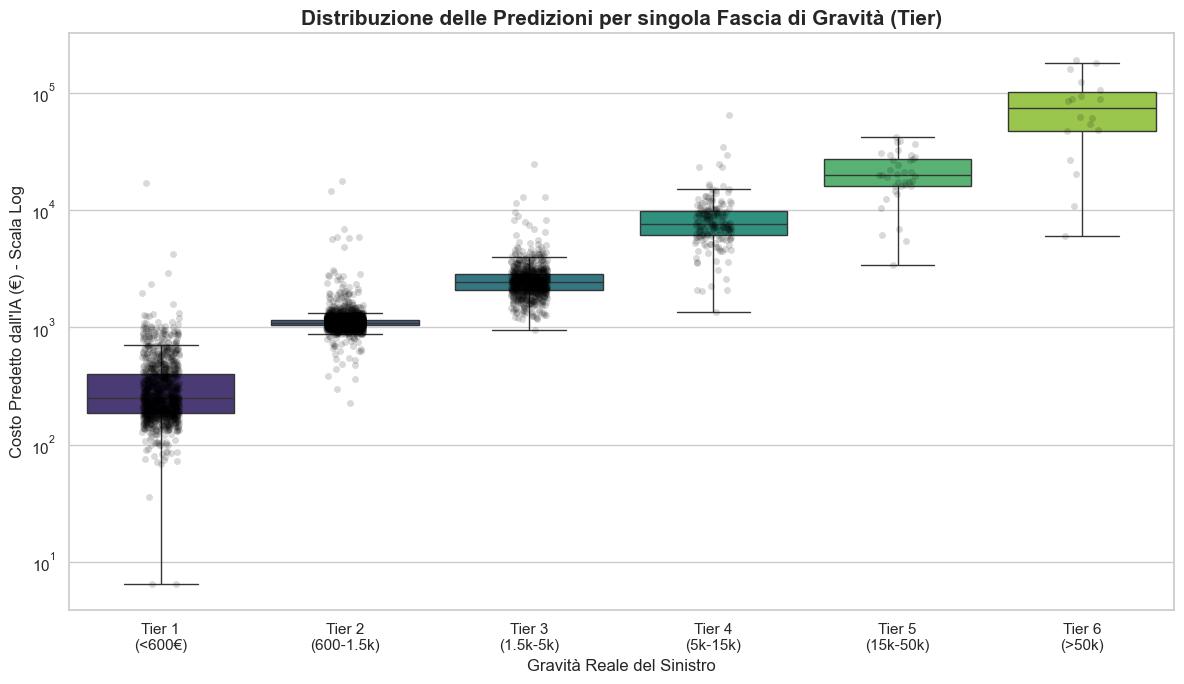

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ESTREIAMO I NUMERI DALLA RETE NEURALE
# Trasformiamo i tensori in liste di numeri semplici
y_true = y_test_tensor.numpy().flatten()
y_pred = predizioni_finali.numpy().flatten()

# 2. CREIAMO DF_RISULTATI AL VOLO (Ecco dove nasce!)
df_risultati = pd.DataFrame({
    'Costo_Reale': y_true,
    'Costo_Predetto': y_pred
})

# 3. DIVIDIAMO IN TIER
bins = [0, 600, 1500, 5000, 15000, 50000, np.inf]
labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
          'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']

df_risultati['Tier_Reale'] = pd.cut(df_risultati['Costo_Reale'], bins=bins, labels=labels)

# 4. DISEGNIAMO IL GRAFICO BOXPLOT
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_risultati, x='Tier_Reale', y='Costo_Predetto', palette="viridis", showfliers=False)
sns.stripplot(data=df_risultati, x='Tier_Reale', y='Costo_Predetto', color='black', alpha=0.15, jitter=True)

plt.yscale('log')
plt.title("Distribuzione delle Predizioni per singola Fascia di Gravità (Tier)", fontsize=15, fontweight='bold')
plt.xlabel("Gravità Reale del Sinistro", fontsize=12)
plt.ylabel("Costo Predetto dall'IA (€) - Scala Log", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\feder\AppData\Local\Temp\ipykernel_9392\2198180800.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


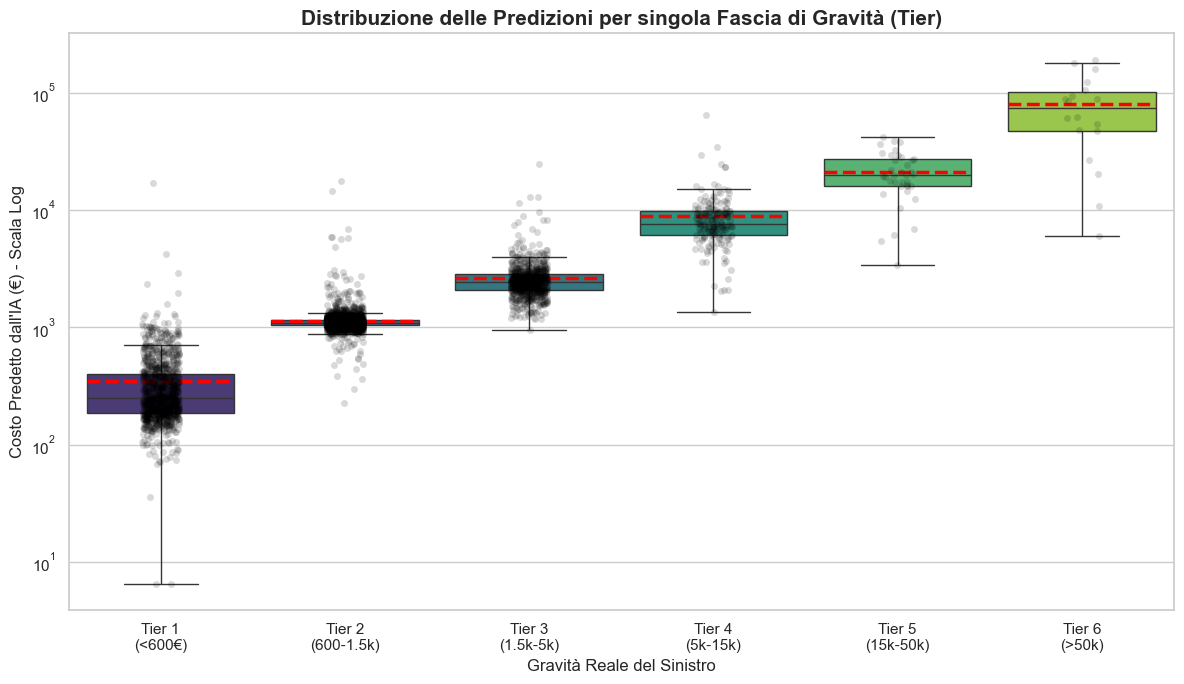

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ESTRAIAMO I NUMERI DALLA RETE NEURALE
y_true = y_test_tensor.numpy().flatten()
y_pred = predizioni_finali.numpy().flatten()

# 2. CREIAMO DF_RISULTATI AL VOLO
df_risultati = pd.DataFrame({
    'Costo_Reale': y_true,
    'Costo_Predetto': y_pred
})

# 3. DIVIDIAMO IN TIER
bins = [0, 600, 1500, 5000, 15000, 50000, np.inf]
labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
          'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']

df_risultati['Tier_Reale'] = pd.cut(df_risultati['Costo_Reale'], bins=bins, labels=labels)

# 4. DISEGNIAMO IL GRAFICO BOXPLOT CON LA MEDIA
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Modifica qui: aggiunti showmeans, meanline e meanprops
sns.boxplot(
    data=df_risultati, 
    x='Tier_Reale', 
    y='Costo_Predetto', 
    palette="viridis", 
    showfliers=False,
    showmeans=True, 
    meanline=True, 
    meanprops={"color": "red", "linewidth": 2.5, "linestyle": "--"}
)

sns.stripplot(data=df_risultati, x='Tier_Reale', y='Costo_Predetto', color='black', alpha=0.15, jitter=True)

plt.yscale('log')
plt.title("Distribuzione delle Predizioni per singola Fascia di Gravità (Tier)", fontsize=15, fontweight='bold')
plt.xlabel("Gravità Reale del Sinistro", fontsize=12)
plt.ylabel("Costo Predetto dall'IA (€) - Scala Log", fontsize=12)

plt.tight_layout()
plt.show()

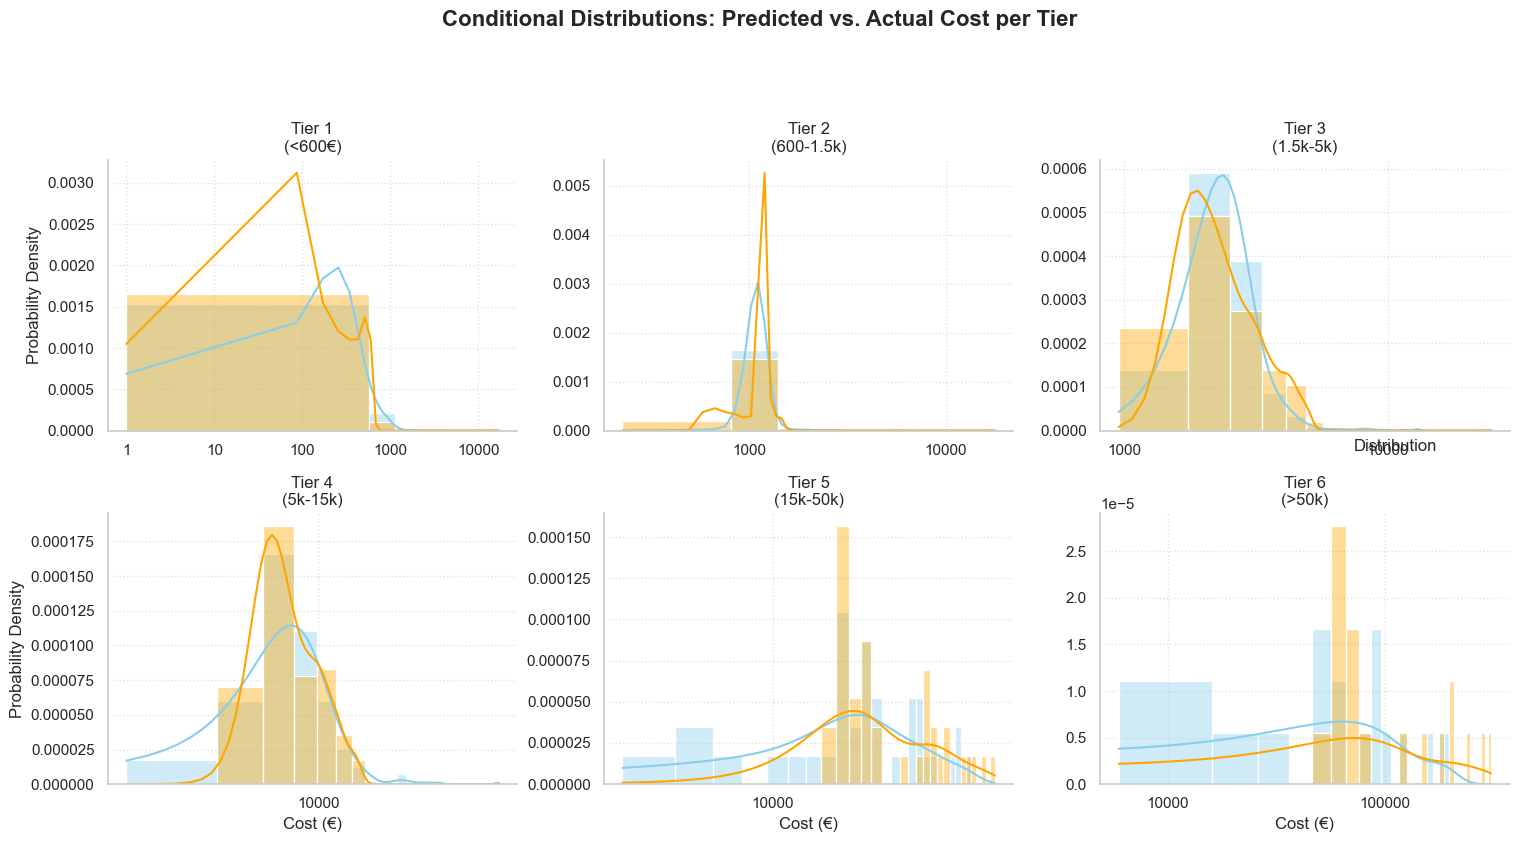

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Maintain df_long (it is perfect for Seaborn)
df_long = df_risultati.melt(
    id_vars=['Tier_Reale'], 
    value_vars=['Costo_Reale', 'Costo_Predetto'],
    var_name='Type', 
    value_name='Cost'
)

# 2. Use histplot with 'common_norm=False'
# This normalizes each histogram independently.
# Crucial for observing the actual CONDITIONAL DISTRIBUTION of each group.
g = sns.FacetGrid(
    df_long, 
    col="Tier_Reale", 
    col_wrap=3, 
    height=4, 
    aspect=1.2,
    sharex=False, 
    sharey=False 
)

g.map_dataframe(
    sns.histplot, 
    x="Cost", 
    hue="Type", 
    palette={"Costo_Reale": "orange", "Costo_Predetto": "skyblue"},
    kde=True, 
    bins=30, 
    alpha=0.4,
    stat="density",     # <--- Crucial: normalizes areas to 1 to compare distribution shapes
    common_norm=False    # <--- Crucial: each distribution is normalized independently
)

# 3. Clean up layout and legend
g.add_legend(title="Distribution", loc='center right', bbox_to_anchor=(0.95, 0.5))
g.set(xscale="log")
g.set_titles("{col_name}")
g.set_axis_labels("Cost (€)", "Probability Density")

for ax in g.axes.flatten():
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Conditional Distributions: Predicted vs. Actual Cost per Tier", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

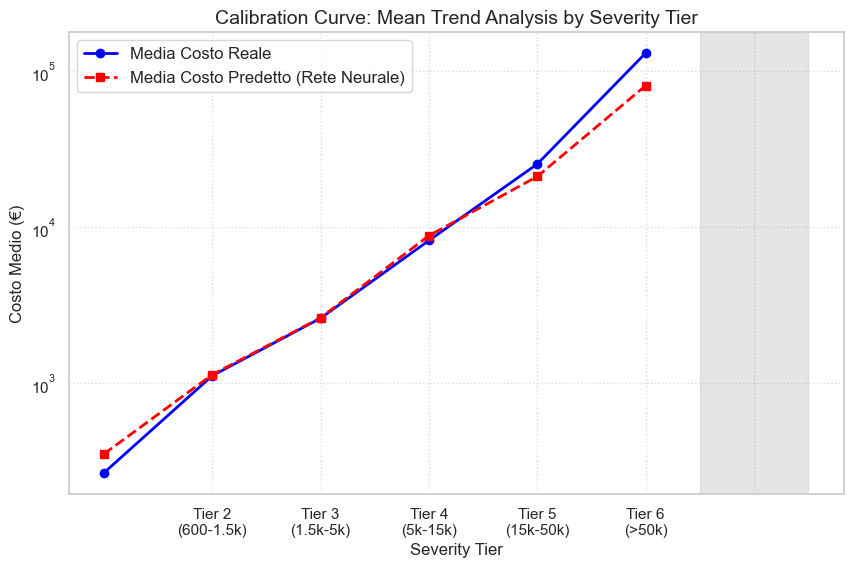

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Calcola le medie per ogni Tier
medie_per_tier = df_risultati.groupby('Tier_Reale')[['Costo_Reale', 'Costo_Predetto']].mean().reset_index()

# Creazione del grafico
plt.figure(figsize=(10, 6))

# Spezzata delle medie reali (La Verità)
plt.plot(medie_per_tier['Tier_Reale'], medie_per_tier['Costo_Reale'], 
         marker='o', linestyle='-', color='blue', linewidth=2, label='Media Costo Reale')

# Spezzata delle medie predette (Il tuo Modello)
plt.plot(medie_per_tier['Tier_Reale'], medie_per_tier['Costo_Predetto'], 
         marker='s', linestyle='--', color='red', linewidth=2, label='Media Costo Predetto (Rete Neurale)')

# Estetica del grafico
plt.title('Calibration Curve: Mean Trend Analysis by Severity Tier', fontsize=14)
plt.xlabel('Severity Tier', fontsize=12)
plt.ylabel('Costo Medio (€)', fontsize=12)
plt.xticks(range(1, 7)) # Assumendo Tier da 1 a 6
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Evidenziare il gap al Tier 6
plt.axvspan(5.5, 6.5, color='gray', alpha=0.2, label='Tail Event Area')
plt.yscale('log')
#plt.ylim(0, 15000)
plt.show()

In [16]:
medie_per_tier

,Tier_Reale,Costo_Reale,Costo_Predetto
0,Tier 1\n(<600€),265.577057,351.052887
1,Tier 2\n(600-1.5k),1114.096558,1131.900513
2,Tier 3\n(1.5k-5k),2605.017090,2621.970703
3,Tier 4\n(5k-15k),8206.278320,8812.164062
4,Tier 5\n(15k-50k),25363.472656,21104.101562
5,Tier 6\n(>50k),130521.460938,80690.140625


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

print("\n" + "="*40)
print("   METRICHE DI VALUTAZIONE MODELLO")
print("="*40)

# In ambito assicurativo, una predizione non può essere negativa.
# Se la rete ha predetto valori negativi (può succedere senza attivazione finale), 
# li portiamo a 0 per non falsare le metriche.
y_pred_clipped = np.maximum(y_pred, 0)

# Calcolo delle metriche
mae = mean_absolute_error(y_true, y_pred_clipped)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
mape = mean_absolute_percentage_error(y_true, y_pred_clipped) * 100


print(f"1. MAE (Errore Assoluto Medio):      {mae:.2f} €")
print(f"2. RMSE (Radice Errore Quadratico):  {rmse:.2f} €")
print(f"3. MAPE (Errore Percentuale Medio):  {mape:.2f} %")

print("="*40 + "\n")


   METRICHE DI VALUTAZIONE MODELLO
1. MAE (Errore Assoluto Medio):      780.90 €
2. RMSE (Radice Errore Quadratico):  6608.18 €
3. MAPE (Errore Percentuale Medio):  94.24 %



### APPLICAZIONE SU DATASET NON SUPERVISIONATO

In [18]:
import pandas as pd
import time

# ==========================================
# 1. CARICAMENTO DATI GREZZI NON SUPERVISIONATI
# ==========================================
print("Caricamento del dataset Non Supervisionato in corso...")
start_time = time.time()
df_unsup = pd.read_csv("freMTPL2_100con_embedding Validation.csv")

# Separiamo le colonne Meta (es. ClaimAmount, ID) dalle colonne Embedding (E_1, E_2...)
colonne_embedding = [col for col in df_unsup.columns if col.startswith('E')]
colonne_meta = [col for col in df_unsup.columns if col not in colonne_embedding]

df_meta_unsup = df_unsup[colonne_meta]
X_grezzi_unsup = df_unsup[colonne_embedding].values

print(f"Trovate {len(colonne_meta)} colonne meta e {len(colonne_embedding)} colonne embedding grezze.")

# ==========================================
# 2. TRASFORMAZIONE COERENTE 
# ==========================================
print("Standardizzazione e Compressione PCA in corso...")

# ATTENZIONE: Usiamo SOLO .transform() usando lo scaler e la pca
X_scaled_unsup = scaler.transform(X_grezzi_unsup)
X_pca_unsup = pca.transform(X_scaled_unsup)

n_componenti = X_pca_unsup.shape[1]
print(f"Dimensioni ridotte correttamente a {n_componenti} componenti PCA.")

# ==========================================
# 3. RICOSTRUZIONE E SALVATAGGIO DEL NUOVO CSV
# ==========================================
# Creiamo il dataframe solo con le colonne PCA
colonne_pca = [f'PCA_{i+1}' for i in range(n_componenti)]
df_pca_unsup = pd.DataFrame(X_pca_unsup, columns=colonne_pca, index=df_unsup.index)

# Riuniamo i meta-dati (es. il ClaimAmount) con i nuovi vettori PCA
df_finale_unsup = pd.concat([df_meta_unsup, df_pca_unsup], axis=1)

nome_output = "freMTPL2_embeddings_PCA_UNSUPERVISED.csv"
print(f"\nSalvataggio del dataset compresso in: {nome_output}...")
df_finale_unsup.to_csv(nome_output, index=False)

end_time = time.time()
print(f"[SUCCESSO] File generato in {round(end_time - start_time, 2)} secondi! Ora è pronto per PyTorch.")

Caricamento del dataset Non Supervisionato in corso...
Trovate 2 colonne meta e 100 colonne embedding grezze.
Standardizzazione e Compressione PCA in corso...
Dimensioni ridotte correttamente a 87 componenti PCA.

Salvataggio del dataset compresso in: freMTPL2_embeddings_PCA_UNSUPERVISED.csv...


c:\Users\feder\OneDrive\Desktop\Tesi\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[SUCCESSO] File generato in 4.72 secondi! Ora è pronto per PyTorch.


In [19]:
# Nello script della Rete Neurale:
df_test_unsup = pd.read_csv("freMTPL2_embeddings_PCA_UNSUPERVISED.csv")
X_test_unsup = df_test_unsup.filter(like='PCA_').values
y_true_unsup = df_test_unsup['ClaimAmount'].values
# ... e passi direttamente X_test_unsup al modello!


 VALUTAZIONE PRESTAZIONI SU DATI NON SUPERVISIONATI
Generazione delle predizioni in corso...

--- NUOVE METRICHE RILEVATE ---
1. MAE (Errore Assoluto Medio):      2427.19 €
2. RMSE (Radice Errore Quadratico):  29371.44 €
3. MAPE (Errore Percentuale Medio):  410.18 %


C:\Users\feder\AppData\Local\Temp\ipykernel_9392\617365044.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


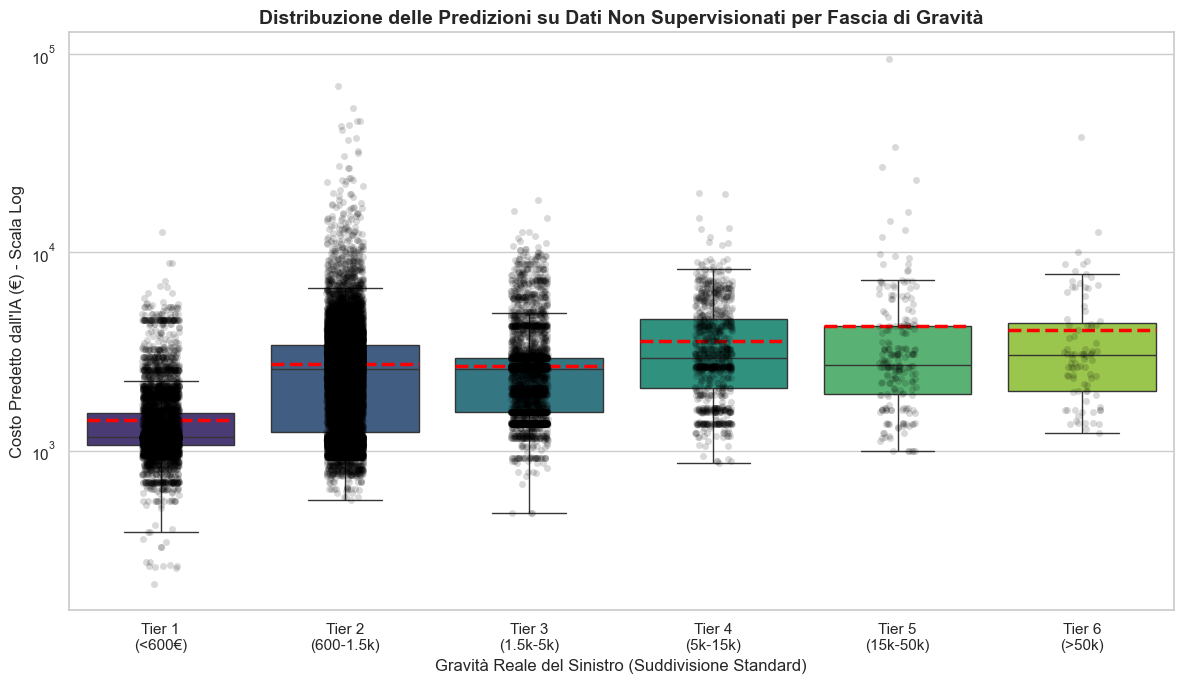

In [20]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n" + "="*50)
print(" VALUTAZIONE PRESTAZIONI SU DATI NON SUPERVISIONATI")
print("="*50)

# 1. CONVERSIONE IN TENSORE PYTORCH
# Convertiamo la matrice PCA appena caricata nel formato float32 per la rete
X_unsup_tensor = torch.tensor(X_test_unsup, dtype=torch.float32)

# 2. INFERENZA CON LA RETE NEURALE
print("Generazione delle predizioni in corso...")
model.eval() # Spegniamo il dropout per la fase di test
with torch.no_grad(): # Disattiviamo il calcolo dei gradienti per risparmiare memoria
    predizioni_tensore = model(X_unsup_tensor)

# Trasformiamo l'output in un array Numpy piatto
y_pred_unsup = predizioni_tensore.numpy().flatten()

# Regola di Business: un sinistro non può avere costo negativo. 
# Se la rete predice un valore sotto lo zero, lo forziamo a 0.
y_pred_unsup = np.maximum(y_pred_unsup, 0)

# ==========================================
# 3. CALCOLO METRICHE MATEMATICHE
# ==========================================
mae_nuovo = mean_absolute_error(y_true_unsup, y_pred_unsup)
rmse_nuovo = np.sqrt(mean_squared_error(y_true_unsup, y_pred_unsup))

# Calcoliamo il MAPE facendo attenzione a non dividere per zero 
# (sostituiamo i costi reali pari a 0 con un valore minimo o li escludiamo)
y_true_safe = np.where(y_true_unsup == 0, 1, y_true_unsup)
mape_nuovo = np.mean(np.abs((y_true_unsup - y_pred_unsup) / y_true_safe)) * 100

print("\n--- NUOVE METRICHE RILEVATE ---")
print(f"1. MAE (Errore Assoluto Medio):      {mae_nuovo:.2f} €")
print(f"2. RMSE (Radice Errore Quadratico):  {rmse_nuovo:.2f} €")
print(f"3. MAPE (Errore Percentuale Medio):  {mape_nuovo:.2f} %")
print("="*50)

# ==========================================
# 4. CREAZIONE GRAFICO DI CONFRONTO (BOXPLOT)
# ==========================================
# Creiamo il DataFrame con i risultati effettivi di questa sessione
df_risultati_nuovi = pd.DataFrame({
    'Costo_Reale': y_true_unsup,
    'Costo_Predetto': y_pred_unsup
})

# Dividiamo nei 6 Tier classici definiti a priori per confrontarlo col primo modello
bins = [0, 600, 1500, 5000, 15000, 50000, np.inf]
labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
          'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']

df_risultati_nuovi['Tier_Reale'] = pd.cut(df_risultati_nuovi['Costo_Reale'], bins=bins, labels=labels)

# Disegniamo il Boxplot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Generiamo il Boxplot evidenziando la MEDIA in rosso tratteggiato
sns.boxplot(
    data=df_risultati_nuovi, 
    x='Tier_Reale', 
    y='Costo_Predetto', 
    palette="viridis", 
    showfliers=False,
    showmeans=True, 
    meanline=True, 
    meanprops={"color": "red", "linewidth": 2.5, "linestyle": "--"}
)

# Sovrapponiamo i punti reali per vedere la densità dei dati
sns.stripplot(data=df_risultati_nuovi, x='Tier_Reale', y='Costo_Predetto', color='black', alpha=0.15, jitter=True)

plt.yscale('log')
plt.title("Distribuzione delle Predizioni su Dati Non Supervisionati per Fascia di Gravità", fontsize=14, fontweight='bold')
plt.xlabel("Gravità Reale del Sinistro (Suddivisione Standard)", fontsize=12)
plt.ylabel("Costo Predetto dall'IA (€) - Scala Log", fontsize=12)

plt.tight_layout()
plt.show()

Ricerca automatica dei cluster di costo (K-Means) sui dati non supervisionati...


C:\Users\feder\AppData\Local\Temp\ipykernel_9392\3033029217.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


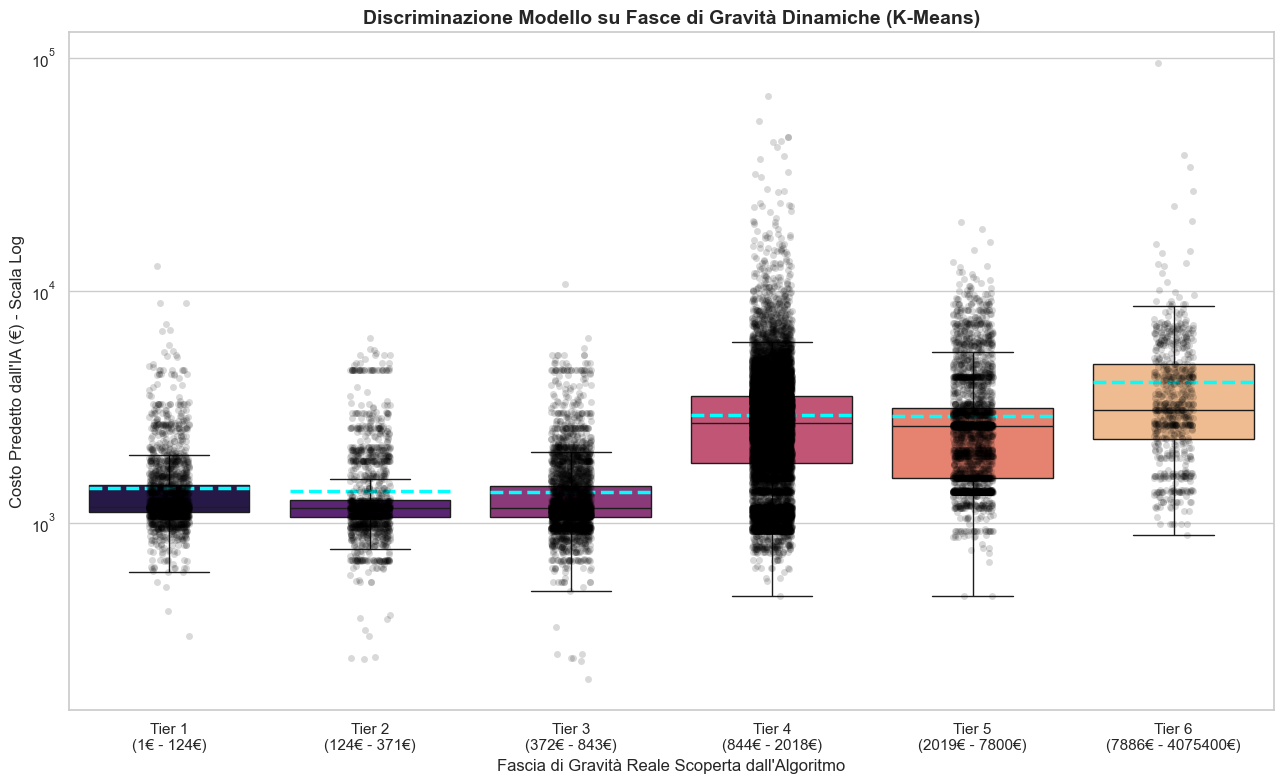

In [21]:
from sklearn.cluster import KMeans

# ==========================================
# 4. SCOPERTA AUTOMATICA DEI TIER (K-MEANS) E GRAFICO
# ==========================================
# Creiamo il DataFrame
df_risultati_nuovi = pd.DataFrame({
    'Costo_Reale': y_true_unsup,
    'Costo_Predetto': y_pred_unsup
})

print("Ricerca automatica dei cluster di costo (K-Means) sui dati non supervisionati...")
# Applichiamo il logaritmo per gestire la coda lunga
costi_log = np.log1p(df_risultati_nuovi['Costo_Reale'].values.reshape(-1, 1))

# Troviamo 6 gruppi naturali (Tier) senza imporre limiti a priori
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(costi_log)

# Riordiniamo i cluster dal più economico al più costoso
centri = kmeans.cluster_centers_.flatten()
ordine = np.argsort(centri)
mappa_riordino = {vecchio_id: f"Tier {nuovo_id + 1}" for nuovo_id, vecchio_id in enumerate(ordine)}

# Assegniamo il nuovo Tier scoperto
df_risultati_nuovi['Tier_Scoperto'] = [mappa_riordino[cid] for cid in cluster_ids]

# Creiamo le etichette con i veri range di prezzo trovati dal K-Means
riassunto = df_risultati_nuovi.groupby('Tier_Scoperto')['Costo_Reale'].agg(['min', 'max'])
etichette_custom = {}
for tier in riassunto.index:
    min_val = int(riassunto.loc[tier, 'min'])
    max_val = int(riassunto.loc[tier, 'max'])
    etichette_custom[tier] = f"{tier}\n({min_val}€ - {max_val}€)"

df_risultati_nuovi['Tier_Dinamico'] = df_risultati_nuovi['Tier_Scoperto'].map(etichette_custom)

# Ordiniamo il dataframe affinché i Tier appaiano da 1 a 6
df_risultati_nuovi = df_risultati_nuovi.sort_values('Costo_Reale')

# ------------------------------------------
# DISEGNIAMO IL GRAFICO BOXPLOT
# ------------------------------------------
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Generiamo il Boxplot usando la suddivisione trovata dal K-Means
sns.boxplot(
    data=df_risultati_nuovi, 
    x='Tier_Dinamico', 
    y='Costo_Predetto', 
    palette="magma",  # Cambiamo colore per distinguerlo dal modello vecchio
    showfliers=False,
    showmeans=True, 
    meanline=True, 
    meanprops={"color": "cyan", "linewidth": 2.5, "linestyle": "--"} # Media azzurra per staccare dal magma
)

sns.stripplot(data=df_risultati_nuovi, x='Tier_Dinamico', y='Costo_Predetto', color='black', alpha=0.15, jitter=True)

plt.yscale('log')
plt.title("Discriminazione Modello su Fasce di Gravità Dinamiche (K-Means)", fontsize=14, fontweight='bold')
plt.xlabel("Fascia di Gravità Reale Scoperta dall'Algoritmo", fontsize=12)
plt.ylabel("Costo Predetto dall'IA (€) - Scala Log", fontsize=12)

plt.tight_layout()
plt.show()

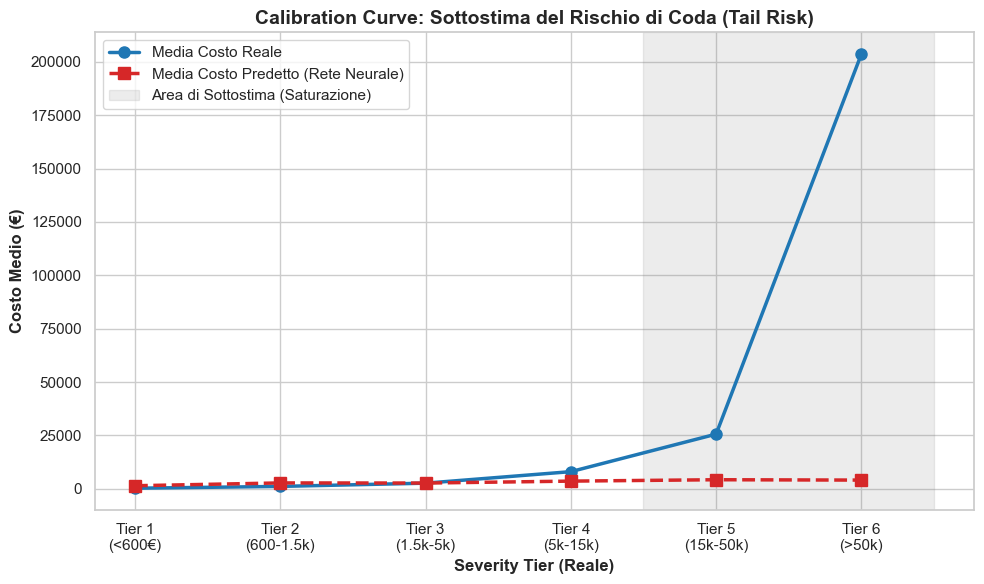

In [22]:
# ==========================================
# 4. CURVA DI CALIBRAZIONE (IL GRAFICO ATTUARIALE)
# ==========================================
# Creiamo il DataFrame con i risultati
df_risultati_nuovi = pd.DataFrame({
    'Costo_Reale': y_true_unsup,
    'Costo_Predetto': y_pred_unsup
})

# Dividiamo nei 6 Tier classici
bins = [0, 600, 1500, 5000, 15000, 50000, np.inf]
labels = ['Tier 1\n(<600€)', 'Tier 2\n(600-1.5k)', 'Tier 3\n(1.5k-5k)', 
          'Tier 4\n(5k-15k)', 'Tier 5\n(15k-50k)', 'Tier 6\n(>50k)']

df_risultati_nuovi['Tier_Reale'] = pd.cut(df_risultati_nuovi['Costo_Reale'], bins=bins, labels=labels)

# Calcoliamo le medie ESATTE per ogni Tier
medie_tier = df_risultati_nuovi.groupby('Tier_Reale')[['Costo_Reale', 'Costo_Predetto']].mean().reset_index()

# Creiamo la Spezzata delle Medie
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Linea dei Costi Reali (Blu)
plt.plot(medie_tier['Tier_Reale'], medie_tier['Costo_Reale'], 
         marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8, label='Media Costo Reale')

# Linea dei Costi Predetti (Rossa)
plt.plot(medie_tier['Tier_Reale'], medie_tier['Costo_Predetto'], 
         marker='s', linestyle='--', color='#d62728', linewidth=2.5, markersize=8, label='Media Costo Predetto (Rete Neurale)')

# Formattazione per la tesi
plt.title("Calibration Curve: Sottostima del Rischio di Coda (Tail Risk)", fontsize=14, fontweight='bold')
plt.xlabel("Severity Tier (Reale)", fontsize=12, fontweight='bold')
plt.ylabel("Costo Medio (€)", fontsize=12, fontweight='bold')

# Evidenziamo l'area critica (Tier 5 e 6)
plt.axvspan(3.5, 5.5, color='gray', alpha=0.15, label='Area di Sottostima (Saturazione)')

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
print(df_risultati_nuovi)

       Costo_Reale  Costo_Predetto          Tier_Reale
0           995.20     1006.579163  Tier 2\n(600-1.5k)
1          1128.12     1002.482849  Tier 2\n(600-1.5k)
2          1851.11     1918.381958   Tier 3\n(1.5k-5k)
3          1204.00      993.162842  Tier 2\n(600-1.5k)
4          1204.00     1474.301880  Tier 2\n(600-1.5k)
...            ...             ...                 ...
26439      1200.00     2582.674561  Tier 2\n(600-1.5k)
26440      1800.00     1561.933472   Tier 3\n(1.5k-5k)
26441      1000.00     1635.716553  Tier 2\n(600-1.5k)
26442       767.55     1067.855591  Tier 2\n(600-1.5k)
26443      1500.00     2607.959473  Tier 2\n(600-1.5k)

[26444 rows x 3 columns]
